# Data preparation

## Importing data

In [1]:
from matplotlib.lines import lineStyles

from main import LinearRegressionFS
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
df.head()


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [2]:
# Creating features and prediction feature
y = df[['addiction_level']]
x = df.drop(['addiction_level'], axis=1)
#x.head(100)

In [3]:
# one hot encoding
x_cat = x[['gender','platform_usage','social_interaction_level']]
x_cat_encoded = pd.get_dummies(x_cat)
x_num = x.drop(x_cat, axis=1)






## Data scaling
- Normalization
- Z-score normalization

In [4]:
# feature scaling (normalization)
x_num_normalized = (x_num - x_num.min()) / (x_num.max()-x_num.min())

#x_num_normalized.describe()

In [5]:
# feature scaling (z-score normalization)
x_num_zscore_normalized = (x_num - x_num.mean()) / (x_num.std())


#x_num_zscore_normalized.describe()

## Categorical and numerical data concatenation

In [6]:
# concat normalized x_num and concatenated x_cat
X= pd.concat([x_cat_encoded, x_num_zscore_normalized], axis=1)
#X.head()

## Splitting training and testing data

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9)
X_train = X_train.to_numpy().astype(np.float64)
X_test = X_test.to_numpy().astype(np.float64)

# Model training with simple hyperparameters

In [8]:
# fitting linear regression, model training
ln_reg  = LinearRegressionFS(learning_rate=0.01, n_iterations=3000)

ln_reg.fit(X_train,y_train)

# Comparison between Scikit-learn and my model's weights

In [9]:
# Comparing my model's weights vs Scikit-learn's model's weights
print("My model's weights: \n" ,ln_reg.w)
from sklearn.linear_model import LinearRegression

line_reg = LinearRegression()
line_reg.fit(X_train,y_train)
print("Scikit-learn model's weights: \n",line_reg.coef_)
print("Scikit-learn model's intercept: \n",line_reg.intercept_)

My model's weights: 
 [[ 2.54713723]
 [ 1.19168165]
 [ 1.35545558]
 [ 0.78256002]
 [ 0.87382054]
 [ 0.89075668]
 [ 0.82886461]
 [ 0.74502205]
 [ 0.97325057]
 [ 0.06084252]
 [-0.15851572]
 [-0.16382245]
 [ 0.04819733]
 [ 0.08792467]
 [ 0.04981945]
 [ 0.00854191]
 [ 0.12872139]
 [-0.01761793]]
Scikit-learn model's weights: 
 [[-0.0818868   0.0818868  -0.06648611  0.02476836  0.04171776 -0.0201801
  -0.10403154  0.12421164  0.06084275 -0.15851592 -0.16382248  0.04819691
   0.08792491  0.04981959  0.00854225  0.12872088 -0.01761841]]
Scikit-learn model's intercept: 
 [5.51879756]


# Visualization of cost history over iterations

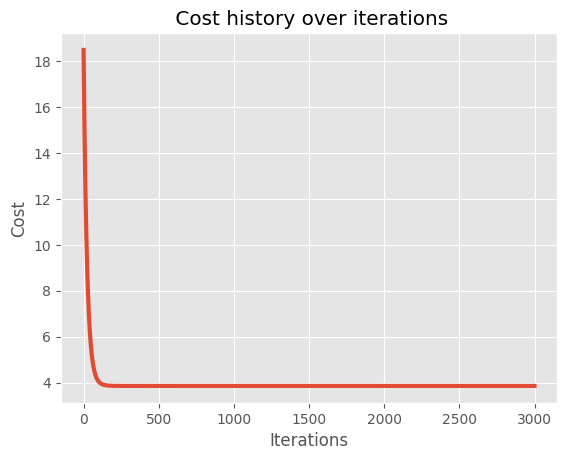

In [10]:
from matplotlib import pyplot as plt

plt.style.use('ggplot')

plt.title(" Cost history over iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")

# plt.figure(facecolor='white')
# ax = plt.gca()
# ax.set_facecolor('white')

plt.plot(ln_reg.cost_history, linewidth = 3)

plt.show()

# Model's accuracy

- $R^2$ (coefficient of determination)
- RMSE

In [11]:
# Printing model's accuracy

y_pred = ln_reg.predict(X_test)
print('R^2: ', ln_reg.accuracy(y_pred, y_test))

R^2:  -0.009561313665659377


In [12]:
from sklearn.metrics import r2_score
sk_pred = line_reg.predict(X_test)
print("Scikit-learn R^2:", r2_score(y_test, sk_pred))

Scikit-learn R^2: -0.009561358530486563
